# Exercise - SAR Prediction in Single Sphere Model (1)

Exercise in the lecture Machine Learning in Electrical Engineering and Information Technology, Prediction of the Specific Absorption Rate (SAR)

* Lecture Period: Summer 2026 ([StudIP](https://e-learning.tuhh.de/studip/dispatch.php/course/details/index/1be148fc0ce85172e3902adf814a909b))
* Institute: Institut für Theoretische Elektrotechnik ([TET](https://www.tet.tuhh.de/en/))
* University: Hamburg University of Technology ([TUHH](https://www.tuhh.de/tuhh/en/startpage))
* Exercise Supervisor: Malte Thode


The first part of the exercise is about the prediction of the Specific Absorption Rate (SAR) inside a single sphere human head model. The sphere represents a single tissue that can vary in its electric properties. The given values are average material electric properties for human head models.

|||
|:-:|:-:|
|<img title="Singel Sphere Head Model" src='figures/Single_Sphere.PNG' width='500'/>|<img title="SAR Distribution using FEM Solver" src='figures/SAR_Single.png' width='500'/>|
|**Singel Sphere Head Model**|**SAR Distribution using FEM Solver**|

### This notebook is structured as follows:
* Loading of required python modules
* Loading the data from the specified CSV file
* Choosing input and output features
* Visualizing the data
* Scaling the data
* Training neural networks
* Evaluating neural networks 

# How to work with the notebook

Each section consists of a couple of cells. The first cell is an introduction to the section and explains the behavior of the following cells. Settings or variables are set in the following cell when needed. Make your settings as you want and run the cell. The cell after is a *code cell*. You do not need to make any settings here, just run the code.

|-|
|:-:|
|<img title="How to Work with the Notebook!" src='figures/cell_setup_2.png' width='700'/>|
|**How to work with the Notebook!**|

#### Module Import
**Modules** are imported, which have to be available to the python interpreter.  
**helper_functions (hp)** is a module in the working directory providing some functions making the notebook more tidy.

**Module Links for Further Information:**
* [pandas](https://pandas.pydata.org/)
* [numpy](https://numpy.org/)
* [matplotlib](https://matplotlib.org/)
* [pickle](https://docs.python.org/3/library/pickle.html)
* [scikit-learn](https://scikit-learn.org/stable/index.html)

In [1]:
# code cell
from sklearn.neural_network import MLPRegressor
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import os as os
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as sm
import numpy as np
import warnings
warnings.filterwarnings('ignore')
# import helper.helper_functions as hp


#### Load Data from Working Directory

From the local directory the CSV file is loaded. The electric properties of the single sphere model (human head average material properties) are varied and given in the table. The ***conductivity*** and ***relative permitivitty*** of single sphere model represent the ***input*** features. The resulting ***SAR*** in the sphere after simulation represent the ***output*** feature.

All data samples are split in **Test** and **Train** data before any operations (scaling, ...) are performed.  

**Variables:**
* *test_size* &rarr; share of data used for testing the trained neural network
* *file_name* &rarr; file containing the data

In [2]:
# variables
test_size = 0.2
file_name = "data/task_1.csv"

In [3]:
# display the data
data_set = pd.read_csv(file_name)
data_set["SAR_single(W/kG)"]=data_set["SAR_single(W/kG)"]*1000
data_set.rename(columns = {'SAR_single(W/kG)':'SAR_single(mW/kg)'}, inplace = True)
pd.set_option('display.max_columns', None)
display(data_set)

,Eps_single,Cond_single(S/m),SAR_single(mW/kg)
0,67.232585,0.761247,0.319046
1,68.312537,0.766427,0.320736
2,86.504520,0.571333,0.261690
3,64.336992,0.604569,0.270796
4,71.400721,0.598778,0.269279
...,...,...,...
245,69.928288,0.787090,0.327374
246,87.655917,0.655012,0.286541
247,63.202543,0.583740,0.264718
248,80.132482,0.751027,0.316262


#### Choosing input and output features

From the loaded file, the input and output features have to be chosen. For this specific task, the electric properties of the sphere are selected as input. The resulting SAR value within the sphere is chosen as the output. The data is then split into training and testing sets for subsequent training and evaluation of neural networks.
* *input_features* &rarr; columns of the data file used as input features
* *output_features* &rarr; columns of the data file used as output features

In [4]:
# variables, choice of the input and output features
input_features=['Eps_single','Cond_single(S/m)']
output_features=['SAR_single(mW/kg)']

In [5]:
# split the data into train and test sets
data_set_train, data_set_test = train_test_split(data_set, test_size=test_size, shuffle=True)

# separate input and output data
train_input = data_set_train[input_features]
train_output = data_set_train[output_features]
test_input = data_set_test[input_features]
test_output = data_set_test[output_features]

#### Data Visualization

Visualizing the distribution of the input and output data is important for better understanding the obtained results. Input parameter combinations from the 250 available samples are shown as scattered points. The output value of each sample is represented by a color according the color bar to the right.

<Axes: xlabel='Eps_single', ylabel='Cond_single(S/m)'>

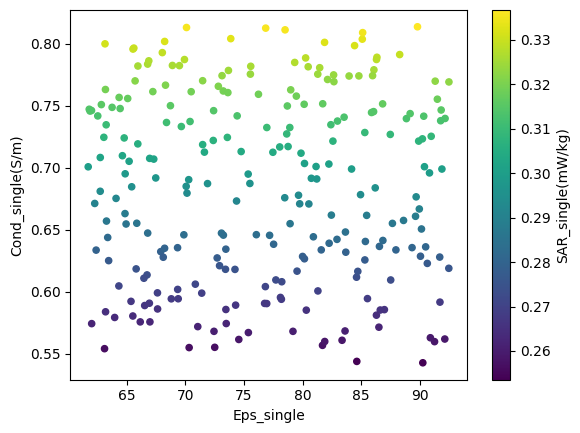

In [6]:
data_set.plot.scatter(x="Eps_single",
                      y="Cond_single(S/m)",
                      c="SAR_single(mW/kg)",
                      colormap='viridis')


#### Scaling of Data
A scaler is used to scale the input features. The scaler is fitted on the train data only, and applied to the train and test data. Feature scaling usually makes the training faster. It prevents the optimization from getting stuck in local optima.

In [7]:
scaler = StandardScaler()
scaler.fit(train_input)

train_input_scaled = scaler.transform(train_input)
test_input_scaled = scaler.transform(test_input)

#### Training Neural Networks

**Sklearn** provides methods to train different kind of machine learning tools e.g. neural networks. To predict the SAR values inside the sphere, we have to define a regressor. The topology and training parameters of the neural network are defined and set before train.

**Variables:**
* *hidden_layer_sizes* &rarr; topologies of neural networks
* *solver* &rarr; solver used during training the neural network and optimizing the weights
* *learning_rate_init* &rarr; initial learning rates used for the solver
* *learning_rate* &rarr; type of learning rate
* *max_iter* &rarr; maximum number of iterations before termination of the training 
* *activation* &rarr; activation function for the hidden layer.
* *alpha* &rarr; strength of the L2 regularization term. 
* *n_iter_no_change* &rarr; maximum number of epochs to not meet tol improvement.
* *early_stopping* &rarr; Whether to use early stopping to terminate training when validation score is not improving

Possible parameters can be identified on https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html


In [8]:
# variables
param_grid = {'hidden_layer_sizes' : (5,),
              'learning_rate_init' : 1e-2,
              'learning_rate' : 'adaptive',
              'solver' : 'adam',
              'max_iter' : 20000,
              'activation' : 'tanh',
              'alpha' : 0.0001,
              'n_iter_no_change' : 50, 
              'tol': 1e-5,
              'early_stopping' : True,
              }

In [9]:
# A regressor is chosen and set according to 
#the previously defined variables
NN = MLPRegressor(**param_grid)

# The model is trained on the training set
NN.fit(train_input_scaled, train_output)


MLPRegressor(activation='tanh', early_stopping=True, hidden_layer_sizes=(5,),
             learning_rate='adaptive', learning_rate_init=0.01, max_iter=20000,
             n_iter_no_change=50, tol=1e-05)

In [10]:
# Predicting unseen test input data by the trained model
NN_pred = NN.predict(test_input_scaled)

#### Evaluating Neural Network Training

After training the neural networks, the networks are evaluated. There are many different metrics to evaluate the performance of the neural network including scores and errors (mean squared error, mean absolute error, ...). Plots of the loss curve and prediction of the test samples give a better insight on the performance.

* *Training and testing scores* &rarr; coefficient of determination R² that measures how well a statistical model predicts an outcome.
* *Mean absolute error* &rarr; average of the absolute errors between predictions and actual values.
* *Mean squared error* &rarr; average of the squares of the errors between predictions and actual values.
* *Median absolute error* &rarr; median of the absolute errors between predictions and actual values.
* *explained variance score* &rarr; measure of the dispersion of errors.
* *most widely used correlation* &rarr; coefficient to measure a linear correlation.

More informations on metrics and scoring on https://scikit-learn.org/stable/modules/model_evaluation.html#model-evaluation

In [16]:
# Scores & Errors
print('training score : ', NN.score(train_input_scaled, train_output))
print('testing score  : ', NN.score(test_input_scaled, test_output))

print("Mean absolute error =", (sm.mean_absolute_error(test_output, NN_pred)))
print("Mean squared error =", (sm.mean_squared_error(test_output, NN_pred)))
print("Median absolute error =", (sm.median_absolute_error(test_output, NN_pred)))
print("Explained variance score =", (sm.explained_variance_score(test_output, NN_pred)))
print("R2 score =", (sm.r2_score(test_output, NN_pred)))
corr, _ = pearsonr(NN_pred, test_output.values.ravel())
print('Pearsons correlation: %.3f' % corr)


training score :  0.9984839402081599
testing score  :  0.9975525620072733
Mean absolute error = 0.0008918562366837157
Mean squared error = 1.2778241174792076e-06
Median absolute error = 0.000738032033087449
Explained variance score = 0.9976564847496082
R2 score = 0.9975525620072733
Pearsons correlation: 0.999


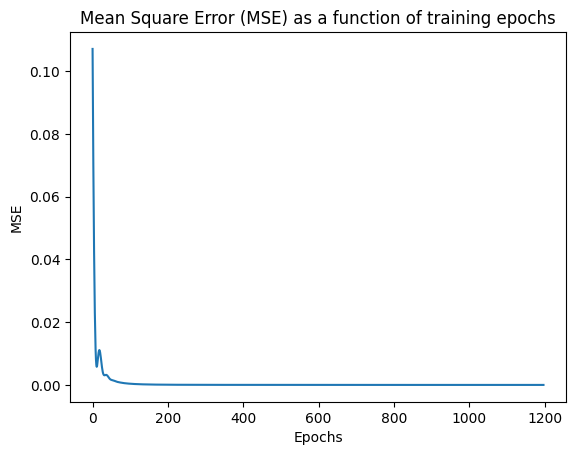

In [17]:
# plot of the evolution of the MSE 

plt.rcParams['figure.dpi'] = 100
plt.plot(NN.loss_curve_)
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Mean Square Error (MSE) as a function of training epochs")
plt.show()

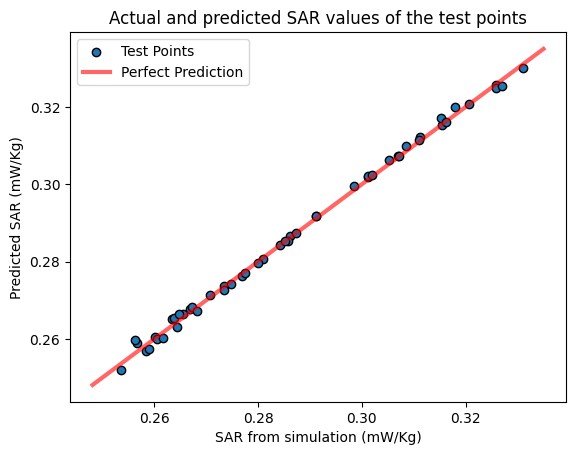

In [18]:
# plot of the actual and predicted SAR, the perfect prediction line is also highlighted for comparison

plt.rcParams['figure.dpi'] = 100
fig, ax = plt.subplots()
ax.scatter(test_output, NN_pred, edgecolors=(0, 0, 0), label='Test Points')
ax.set_xlabel("SAR from simulation (mW/Kg)")
ax.set_ylabel("Predicted SAR (mW/Kg)")
# Fixed: renamed min/max variables to avoid shadowing Python built-ins
ax_min = min(ax.get_xlim()[0], ax.get_ylim()[0])
ax_max = max(ax.get_xlim()[-1], ax.get_ylim()[-1])
ax.plot([ax_min, ax_max], [ax_min, ax_max], label='Perfect Prediction', c='r', lw=3, alpha=0.6)
plt.title("Actual and predicted SAR values of the test points")
ax.legend()
plt.show()


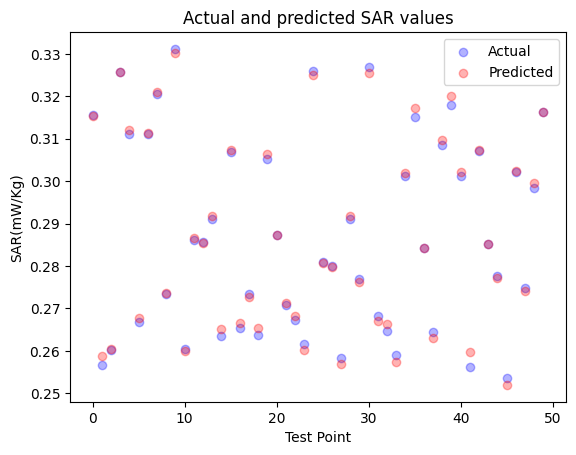

In [19]:
# plot of the actual and predicted SAR  at test points

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
fig, ax = plt.subplots()
ax.scatter(x=range(0, test_output.size), y=test_output , c='blue', label='Actual', alpha=0.3)
ax.scatter(x=range(0, NN_pred.size), y=NN_pred, c='red', label='Predicted', alpha=0.3)
plt.title('Actual and predicted SAR values')
plt.xlabel('Test Point')
plt.ylabel('SAR(mW/Kg)')
plt.legend(loc='best')
plt.show()

#### Guiding Questions

**Do we need a neural network for this problem?**  


**What other possible solutions could be used instead of ANN?**  


**Do we need data scaling as preprocessing?**  


**Is there any effect of data splitting in the ANN evaluation result?**  

